# VIX Mean Reversion — Implementation Comparison

Loads trades from `results/vix_mean_reversion_trades.csv`.

**Architecture:** Single instrument (SVXY) — no sleeves needed.
Simpler than the multi-sleeve strategies.

**Methods:** Simple bet, Risk-based (has -20% stop), Fixed Kelly, Asset vol.
**Leverage:** 1x, 2x, 4x, 8x. Kelly: Quarter=1x, Half=2x, Full=4x, Double=8x.

## 1. Setup

In [8]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.implementations import (
    simple_bet, risk_based, asset_vol_targeting,
    build_daily_equity,
)

STARTING_CAPITAL = 100_000
STRATEGY_NAME = "VIX Mean Reversion"
SAVE_NAME     = "vix_mean_reversion"
INSTRUMENT    = "SVXY"

pd.set_option("display.max_columns", None)

## 2. Load Signal Trades & Daily Prices

In [9]:
trades = pd.read_csv(f"results/{SAVE_NAME}_trades.csv",
                      parse_dates=["entry_time", "exit_time"])
print(f"Loaded {len(trades)} trades")
print(f"Period: {trades['entry_time'].iloc[0].date()} -> {trades['exit_time'].iloc[-1].date()}")
print(f"Avg hold days: {(trades['exit_time'] - trades['entry_time']).dt.days.mean():.1f}")
print(f"Has stop_price: {trades['stop_price'].notna().sum()} / {len(trades)}")
print(f"Exit reasons: {dict(trades['exit_reason'].value_counts())}")

# Daily prices for mark-to-market and asset_vol_targeting
START_DATE = str(trades["entry_time"].iloc[0].date())
END_DATE   = str(trades["exit_time"].iloc[-1].date())

daily_data = fetch_historical_data(
    [INSTRUMENT], TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)
d = daily_data[INSTRUMENT].reset_index()
d["date"] = pd.to_datetime(d["timestamp"]).dt.tz_localize(None).dt.normalize()
daily_prices = d.set_index("date")["close"]
daily_for_avt = d[["date", "close"]].set_index("date")
print(f"\n{INSTRUMENT}: {len(daily_prices)} daily bars")

Loaded 72 trades
Period: 2016-06-14 -> 2026-03-31
Avg hold days: 5.5
Has stop_price: 72 / 72
Exit reasons: {'signal': 70, 'stop_loss': 1, 'end_of_data': 1}
Fetching SVXY...
  2,462 bars

SVXY: 2462 daily bars


## 3. Sizing Helpers

Single instrument — no sleeves. Each sizing function runs directly on
the full trade stream. Daily equity uses mark-to-market.

In [10]:
def _add_shares(trades_df, shares_per_trade):
    t = trades_df.copy()
    t["shares"] = shares_per_trade
    return t

def run_sizing(sizing_fn, label, **kwargs):
    """Run sizing, build daily equity with mark-to-market, compute stats."""
    res = sizing_fn(trades, starting_capital=STARTING_CAPITAL, **kwargs)
    t_with_shares = _add_shares(trades, res["shares_per_trade"])
    daily_eq = build_daily_equity(
        t_with_shares, res["equity_curve"], STARTING_CAPITAL,
        daily_prices=daily_prices)

    daily_returns = daily_eq.pct_change().dropna()
    total_return = (daily_eq.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ann_sharpe = (daily_returns.mean() / daily_returns.std() * np.sqrt(252)
                   if daily_returns.std() > 0 else 0)
    peak = daily_eq.expanding().max()
    max_dd = ((daily_eq - peak) / peak).min() * 100
    years = (daily_eq.index[-1] - daily_eq.index[0]).days / 365.25
    cagr = ((daily_eq.iloc[-1] / STARTING_CAPITAL) ** (1 / years) - 1) * 100 if years > 0 else 0

    return {
        "label": label, "daily_equity": daily_eq,
        "stats": {
            "total_return": round(total_return, 1),
            "cagr": round(cagr, 2),
            "sharpe": round(ann_sharpe, 2),
            "max_dd": round(max_dd, 1),
        },
    }

def run_asset_vol(target_vol, lookback, max_leverage, label):
    """asset_vol_targeting wrapper."""
    res = asset_vol_targeting(trades, daily_for_avt,
                                target_vol=target_vol, lookback=lookback,
                                max_leverage=max_leverage,
                                starting_capital=STARTING_CAPITAL)
    t_with_shares = _add_shares(trades, res["shares_per_trade"])
    daily_eq = build_daily_equity(
        t_with_shares, res["equity_curve"], STARTING_CAPITAL,
        daily_prices=daily_prices)

    daily_returns = daily_eq.pct_change().dropna()
    total_return = (daily_eq.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ann_sharpe = (daily_returns.mean() / daily_returns.std() * np.sqrt(252)
                   if daily_returns.std() > 0 else 0)
    peak = daily_eq.expanding().max()
    max_dd = ((daily_eq - peak) / peak).min() * 100
    years = (daily_eq.index[-1] - daily_eq.index[0]).days / 365.25
    cagr = ((daily_eq.iloc[-1] / STARTING_CAPITAL) ** (1 / years) - 1) * 100 if years > 0 else 0

    return {
        "label": label, "daily_equity": daily_eq,
        "stats": {
            "total_return": round(total_return, 1),
            "cagr": round(cagr, 2),
            "sharpe": round(ann_sharpe, 2),
            "max_dd": round(max_dd, 1),
        },
    }

def print_comparison(results):
    print(f"{'Label':<45} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
    print("-" * 85)
    for r in results:
        s = r["stats"]
        print(f"{r['label']:<45} {s['total_return']:>10,.1f} {s['cagr']:>8.2f} "
              f"{s['sharpe']:>8.2f} {s['max_dd']:>8.1f}")

## 4. Base Sizing Comparison (1x)

Four methods. VIX MR has a -20% stop, so risk-based sizes by stop distance.
With a 20% stop, risk-based bets equity * 0.01 / (0.20 * price) = 5% bet — very conservative.

In [11]:
# ── Compute Kelly f* ──
rets_all = trades["pct_return_gross"].values
wins_all = rets_all[rets_all > 0]
losses_all = rets_all[rets_all < 0]
if len(wins_all) >= 3 and len(losses_all) >= 1:
    p = len(wins_all) / len(rets_all)
    b = wins_all.mean() / abs(losses_all.mean())
    KELLY_F = max((p * b - (1 - p)) / b, 0.01)
else:
    KELLY_F = 0.10

print(f"Kelly f* from {len(trades)} trades:")
print(f"  Win rate: {p*100:.1f}%, W/L ratio: {b:.2f}")
print(f"  Full Kelly f*: {KELLY_F:.2%}")
print(f"  Quarter={KELLY_F*0.25:.1%}, Half={KELLY_F*0.5:.1%}, "
      f"Full={KELLY_F:.1%}, Double={KELLY_F*2:.1%}\n")

def _simple(trades, starting_capital, bet_size):
    return simple_bet(trades, bet_size=bet_size, starting_capital=starting_capital)

def _risk(trades, starting_capital, risk_pct, leverage):
    return risk_based(trades, risk_pct=risk_pct, leverage=leverage,
                       starting_capital=starting_capital)

def _kelly(trades, starting_capital, kelly_mult):
    return simple_bet(trades, bet_size=KELLY_F * kelly_mult,
                       starting_capital=starting_capital)

Kelly f* from 72 trades:
  Win rate: 79.2%, W/L ratio: 1.63
  Full Kelly f*: 66.42%
  Quarter=16.6%, Half=33.2%, Full=66.4%, Double=132.8%



In [12]:
r_simple = run_sizing(_simple, label="Simple bet 85% (1x)", bet_size=0.85)
r_risk   = run_sizing(_risk,   label="Risk-based 1%, 1x", risk_pct=0.01, leverage=1)
r_kelly  = run_sizing(_kelly,  label=f"Quarter Kelly {KELLY_F*0.25:.0%} (1x)", kelly_mult=0.25)
r_avt    = run_asset_vol(target_vol=0.10, lookback=60, max_leverage=1.0,
                          label="Asset vol 10%, 1x")

base_results = [r_simple, r_risk, r_kelly, r_avt]
print("BASE COMPARISON (1x):\n")
print_comparison(base_results)

BASE COMPARISON (1x):

Label                                            TotRet%    CAGR%   Sharpe   MaxDD%
-------------------------------------------------------------------------------------
Simple bet 85% (1x)                                448.7    18.98     1.20    -19.8
Risk-based 1%, 1x                                   11.1     1.08     1.20     -1.2
Quarter Kelly 17% (1x)                              41.6     3.62     1.20     -4.0
Asset vol 10%, 1x                                  595.7    21.90     1.20    -23.2


## 5. Leverage Sweep

All 4 methods at 2x, 4x, 8x.
Kelly: Quarter=1x, Half=2x, Full=4x, Double=8x.

In [13]:
KELLY_MAP = {1: 0.25, 2: 0.5, 4: 1.0, 8: 2.0}
KELLY_NAMES = {1: "Quarter", 2: "Half", 4: "Full", 8: "Double"}

LEVERAGE_LEVELS = [2, 4, 8]
sweep_results = {}

for lev in LEVERAGE_LEVELS:
    sweep_results[lev] = [
        run_sizing(_simple, label=f"Simple bet {int(85*lev)}% ({lev}x)",
                    bet_size=0.85 * lev),
        run_sizing(_risk, label=f"Risk-based 1%, {lev}x",
                    risk_pct=0.01, leverage=lev),
        run_sizing(_kelly, label=f"{KELLY_NAMES[lev]} Kelly {KELLY_F*KELLY_MAP[lev]:.0%} ({lev}x)",
                    kelly_mult=KELLY_MAP[lev]),
        run_asset_vol(target_vol=0.10, lookback=60, max_leverage=float(lev),
                       label=f"Asset vol 10%, {lev}x"),
    ]

print("ALL METHODS AT 4x:\n")
print_comparison(sweep_results[4])

print("\n\nSIMPLE BET -- SWEEP:")
print_comparison([base_results[0]] + [sr[0] for sr in sweep_results.values()])

print("\nRISK-BASED -- SWEEP:")
print_comparison([base_results[1]] + [sr[1] for sr in sweep_results.values()])

print("\nKELLY -- SWEEP (Quarter->Half->Full->Double):")
print_comparison([base_results[2]] + [sr[2] for sr in sweep_results.values()])

print("\nASSET VOL -- SWEEP:")
print_comparison([base_results[3]] + [sr[3] for sr in sweep_results.values()])

C:\Users\danie\AppData\Local\Temp\ipykernel_4888\826049348.py:21: RuntimeWarning: invalid value encountered in scalar power
  cagr = ((daily_eq.iloc[-1] / STARTING_CAPITAL) ** (1 / years) - 1) * 100 if years > 0 else 0


ALL METHODS AT 4x:

Label                                            TotRet%    CAGR%   Sharpe   MaxDD%
-------------------------------------------------------------------------------------
Simple bet 340% (4x)                            30,428.3    79.36     1.20    -70.7
Risk-based 1%, 4x                                   11.1     1.08     1.20     -1.2
Full Kelly 66% (4x)                                284.2    14.73     1.20    -15.6
Asset vol 10%, 4x                                8,509.4    57.61     1.00    -80.2


SIMPLE BET -- SWEEP:
Label                                            TotRet%    CAGR%   Sharpe   MaxDD%
-------------------------------------------------------------------------------------
Simple bet 85% (1x)                                448.7    18.98     1.20    -19.8
Simple bet 170% (2x)                             2,427.1    39.07     1.21    -38.1
Simple bet 340% (4x)                            30,428.3    79.36     1.20    -70.7
Simple bet 680% (8x)         

## 6. Equity Curves

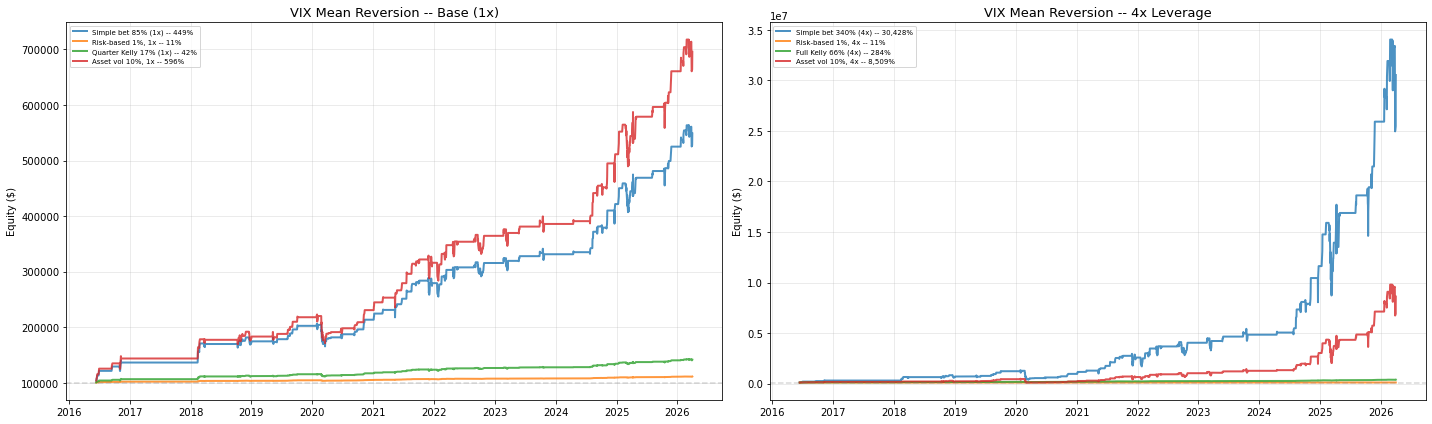

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
ax = axes[0]
for r in base_results:
    eq = r["daily_equity"]
    ret = (eq.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(eq.index.to_numpy(), eq.values, linewidth=2, alpha=0.8,
            label=f"{r['label']} -- {ret:,.0f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} -- Base (1x)", fontsize=13)
ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")

ax = axes[1]
for r in sweep_results[4]:
    eq = r["daily_equity"]
    ret = (eq.iloc[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(eq.index.to_numpy(), eq.values, linewidth=2, alpha=0.8,
            label=f"{r['label']} -- {ret:,.0f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} -- 4x Leverage", fontsize=13)
ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

## 7. Save

In [ ]:
import os, json

def _key(label):
    return (label.lower().replace(" ", "_").replace("(", "").replace(")", "")
             .replace("%", "pct").replace("=", "").replace(",", "")
             .replace("--", ""))

os.makedirs("results", exist_ok=True)
impl_summary = {}
all_results = base_results[:]
for results in sweep_results.values():
    all_results.extend(results)

for r in all_results:
    k = _key(r["label"])
    impl_summary[k] = dict(r["stats"])
    impl_summary[k]["label"] = r["label"]

viable = [r for r in all_results if r["stats"]["max_dd"] > -50]
if viable:
    best = max(viable, key=lambda r: r["stats"]["sharpe"])
    impl_summary["_recommended"] = best["label"]
    print(f"Recommended: {best['label']}")
    print(f"  Sharpe={best['stats']['sharpe']}, Return={best['stats']['total_return']}%,"
          f" MaxDD={best['stats']['max_dd']}%, CAGR={best['stats']['cagr']}%")

with open(f"results/{SAVE_NAME}_implementations.json", "w") as f:
    json.dump(impl_summary, f, indent=2)
print(f"\nSaved {len(impl_summary) - 1} implementations")

eq_dir = f"results/{SAVE_NAME}_daily_equity"
os.makedirs(eq_dir, exist_ok=True)
for r in all_results:
    r["daily_equity"].to_csv(f"{eq_dir}/{_key(r['label'])}.csv")
print(f"Saved {len(all_results)} daily equity curves -> {eq_dir}/")